# 05 -- Strategie 3 : Augmentation de Donnees par Retro-traduction

| | |
|---|---|
| **Projet** | Gestion du Desequilibre de Classes pour l Analyse de Sentiments en Darija Algerien |
| **Etudiant** | Abdelaziz Merzoug |
| **Module** | Machine Learning -- Master 1 DS & NLP -- USDB Blida 1 |
| **Encadrante** | Dr. Soraya Cheriguene |
| **Semaine** | 5 (12-19 Avril 2026) |
| **Plateforme** | Google Colab -- GPU T4 |

---

## Objectifs de ce notebook

Les Strategies 1 (modification de la perte) et 2 (reequilibrage des embeddings) n ont pas
ameliore significativement le F1-macro au-dela du Baseline (0.6805). La Strategie 3 agit
**directement sur les donnees textuelles** en generant de nouvelles paraphrases par retro-traduction.

### Pipeline de retro-traduction (Back-Translation)

```
Tweet Neutral (darija) --[Helsinki-NLP/opus-mt-ar-fr]--> Traduction FR
                                                           |
Tweet augmente (MSA)   <--[Helsinki-NLP/opus-mt-fr-ar]---'
```

### Important -- Derive MSA attendue

Helsinki-NLP a ete entraine sur des corpus MSA (Modern Standard Arabic) : textes des Nations
Unies, articles de presse, sous-titres. Le darija algerien est quasiment absent de ces corpus.
Les paraphrases produites seront donc en **arabe standard**, pas en darija. Cette derive est
**attendue** et sera documentee dans la discussion.

### 3 taux d augmentation testes

| Taux | Neutral original (452) | Ajout | Neutral final |
|------|----------------------|-------|---------------|
| +20% | 452 | ~90 | ~542 |
| +50% | 452 | ~226 | ~678 |
| +100% | 452 | ~452 | ~904 |

### Filtrage par similarite cosinus [0.50, 0.85]

Chaque paraphrase est filtree par similarite cosinus avec l original :
- **< 0.50** : le sens a trop change (risque de flip de sentiment) -- rejetee
- **> 0.85** : trop proche de l original (pas de diversite lexicale) -- rejetee
- **[0.50, 0.85]** : paraphrase valide -- conservee

### Contraintes du protocole

- Augmenter **UNIQUEMENT** la classe Neutral du train set
- Test set et val set **jamais touches**
- Recharger DziriBERT `from_pretrained` **avant chaque fine-tuning**
- `random_state=42` partout
- `try/except` obligatoire sur chaque appel Helsinki-NLP

In [3]:
# =============================================================================
# CELLULE 0 -- Montage Google Drive + verification GPU
# =============================================================================
from google.colab import drive
drive.mount('/content/drive')
BASE = '/content/drive/MyDrive/mini_projet_darija'

import torch, os
assert torch.cuda.is_available(), 'GPU NON DISPONIBLE -- changer le runtime !'
print(f'GPU : {torch.cuda.get_device_name(0)}')
print(f'VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} Go')
print(f'Drive montee. BASE = {BASE}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU : Tesla T4
VRAM : 15.6 Go
Drive montee. BASE = /content/drive/MyDrive/mini_projet_darija


In [4]:
# =============================================================================
# Installation des dependances
# =============================================================================
!pip install -q transformers datasets torch scikit-learn imbalanced-learn \
    pandas numpy matplotlib seaborn emoji accelerate sentencepiece sacremoses

# =============================================================================
# Graines aleatoires -- fixees AVANT tout import aleatoire
# =============================================================================
import os
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Reproductibilite CUDA (leger ralentissement acceptable)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# =============================================================================
# Imports
# =============================================================================
import re
import json
import shutil
import gc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import emoji
from collections import Counter

from datasets import load_dataset
from sklearn.metrics import (
    f1_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
    average_precision_score, accuracy_score
)
from sklearn.preprocessing import label_binarize
from imblearn.metrics import geometric_mean_score

from transformers import (
    AutoTokenizer, AutoModel, AutoModelForSequenceClassification,
    MarianMTModel, MarianTokenizer,
    Trainer, TrainingArguments, DataCollatorWithPadding
)

# =============================================================================
# Constantes nommees -- identiques dans TOUS les notebooks
# =============================================================================
TEXT_COL   = 'Post'
LABEL_COL  = 'Polarity Class'
LANG_COL   = 'lang'
SEED       = 42

MODEL_NAME = 'alger-ia/dziribert'
EPOCHS     = 5
LR         = 2e-5
BATCH_SIZE = 16

# Mapping coherent des labels -- identique dans TOUS les notebooks
LABEL_MAP   = {'Positive': 0, 'Negative': 1, 'Neutral': 2}
LABEL_NAMES = ['Positive', 'Negative', 'Neutral']

# Seuils de filtrage cosinus (imposes par l Enonce)
COS_MIN = 0.50
COS_MAX = 0.85

# Taux d augmentation a tester
AUG_RATES = {'20pct': 0.20, '50pct': 0.50, '100pct': 1.00}

# =============================================================================
# Verification GPU
# =============================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    gpu_props = torch.cuda.get_device_properties(0)
    print(f'GPU    : {gpu_props.name}')
    print(f'VRAM   : {gpu_props.total_memory / 1e9:.1f} Go')

# Creation des repertoires de travail
for d in ['data', 'models', 'results', 'figures', 'logs']:
    os.makedirs(d, exist_ok=True)

print('\nEnvironnement configure avec succes.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 49.7 MB/s eta 0:00:00
Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 Go

Environnement configure avec succes.


In [5]:
# =============================================================================
# Copier les fichiers critiques depuis Drive vers local
# split_indices.json : indices figes du NB02 -- JAMAIS re-split
# =============================================================================
shutil.copy(f'{BASE}/data/split_indices.json', 'data/split_indices.json')
print('split_indices.json copie depuis Drive.')

# Copier les metriques precedentes pour comparaison
shutil.copy(f'{BASE}/results/baseline_metrics.json', 'results/baseline_metrics.json')
print('baseline_metrics.json copie depuis Drive.')

# Copier les metriques de la Strategie 1 et 2
for fname in ['fl_g2_metrics.json', 'cw_metrics.json', 'fl_g1_metrics.json',
              'cw_fl_metrics.json', 'smote_full_metrics.json',
              'smote_partial_metrics.json', 'adasyn_metrics.json']:
    src = f'{BASE}/results/{fname}'
    if os.path.exists(src):
        shutil.copy(src, f'results/{fname}')
        print(f'{fname} copie depuis Drive.')

# Verification des indices
with open('data/split_indices.json') as f:
    split_indices = json.load(f)

n_train = len(split_indices['train_indices'])
n_val   = len(split_indices['val_indices'])
n_test  = len(split_indices['test_indices'])
n_total = n_train + n_val + n_test

print(f'\n=== Verification split_indices.json ===')
print(f'  Train : {n_train} | Val : {n_val} | Test : {n_test} | Total : {n_total}')

# Charger le baseline pour reference
with open('results/baseline_metrics.json') as f:
    baseline_metrics = json.load(f)
print(f'  Baseline F1-macro = {baseline_metrics["f1_macro"]:.4f}')

split_indices.json copie depuis Drive.
baseline_metrics.json copie depuis Drive.
fl_g2_metrics.json copie depuis Drive.
cw_metrics.json copie depuis Drive.
fl_g1_metrics.json copie depuis Drive.
cw_fl_metrics.json copie depuis Drive.
smote_full_metrics.json copie depuis Drive.
smote_partial_metrics.json copie depuis Drive.
adasyn_metrics.json copie depuis Drive.

=== Verification split_indices.json ===
  Train : 3440 | Val : 738 | Test : 738 | Total : 4916
  Baseline F1-macro = 0.6805


---

## Chargement des donnees et preprocessing identique au NB02

On recharge le corpus TWIFL et on applique le **meme pipeline de preprocessing**
que le Notebook 02. Les indices de split sont ensuite charges depuis `split_indices.json`
(jamais re-generes).

In [6]:
# =============================================================================
# Chargement du corpus TWIFL depuis HuggingFace
# =============================================================================
dataset = load_dataset('arbml/Twifil')
df = dataset['train'].to_pandas()

print(f'Shape initiale : {df.shape}')
print(f'Distribution initiale :')
print(df[LABEL_COL].value_counts())

# =============================================================================
# Preprocessing IDENTIQUE au Notebook 02
# =============================================================================

def remove_urls(text):
    """Supprime les URLs (http, https, www)."""
    return re.sub(r'https?://\S+|www\.\S+', '', text)

def remove_mentions(text):
    """Supprime les mentions Twitter (@username)."""
    return re.sub(r'@\w+', '', text)

def convert_emojis(text):
    """Convertit les emojis en texte descriptif anglais."""
    return emoji.demojize(text, delimiters=(' ', ' '))

def remove_hashtag_symbol(text):
    """Supprime le # mais garde le texte du hashtag."""
    return text.replace('#', '')

def normalize_whitespace(text):
    """Normalise les espaces multiples."""
    return re.sub(r'\s+', ' ', text).strip()

def normalize_repeated_chars(text):
    """Reduit les repetitions excessives (max 2 consecutifs)."""
    return re.sub(r'(.)\1{2,}', r'\1\1', text)

def normalize_arabic_digits(text):
    """Convertit les chiffres arabes-indiens en chiffres occidentaux."""
    arabic_to_western = str.maketrans(
        '\u0660\u0661\u0662\u0663\u0664\u0665\u0666\u0667\u0668\u0669',
        '0123456789'
    )
    return text.translate(arabic_to_western)

# Application sequentielle -- meme ordre que NB02
df_clean = df[[TEXT_COL, LABEL_COL, LANG_COL]].copy()
df_clean[TEXT_COL] = df_clean[TEXT_COL].astype(str)

df_clean[TEXT_COL] = df_clean[TEXT_COL].apply(remove_urls)
df_clean[TEXT_COL] = df_clean[TEXT_COL].apply(remove_mentions)
df_clean[TEXT_COL] = df_clean[TEXT_COL].apply(convert_emojis)
df_clean[TEXT_COL] = df_clean[TEXT_COL].apply(remove_hashtag_symbol)
df_clean[TEXT_COL] = df_clean[TEXT_COL].apply(normalize_whitespace)
df_clean[TEXT_COL] = df_clean[TEXT_COL].apply(normalize_repeated_chars)
df_clean[TEXT_COL] = df_clean[TEXT_COL].apply(normalize_arabic_digits)

# Suppression des doublons (texte identique apres nettoyage)
df_clean = df_clean.drop_duplicates(subset=TEXT_COL, keep='first').reset_index(drop=True)

# Suppression des tweets vides/quasi-vides (< 2 caracteres)
empty_mask = df_clean[TEXT_COL].str.strip().str.len() < 2
df_clean = df_clean[~empty_mask].reset_index(drop=True)

print(f'Shape apres preprocessing : {df_clean.shape}')
print(f'\nDistribution des classes :')
for cls in LABEL_NAMES:
    n = (df_clean[LABEL_COL] == cls).sum()
    print(f'  {cls:10s} : {n:4d} ({n/len(df_clean)*100:.1f}%)')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


data/train-00000-of-00001-eef2e32ea1bb4a(…):   0%|          | 0.00/699k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6000 [00:00<?, ? examples/s]

Shape initiale : (6000, 16)
Distribution initiale :
Polarity Class
Positive    2864
Negative    1773
Neutral     1363
Name: count, dtype: int64
Shape apres preprocessing : (4916, 3)

Distribution des classes :
  Positive   : 2541 (51.7%)
  Negative   : 1729 (35.2%)
  Neutral    :  646 (13.1%)


In [7]:
# =============================================================================
# Reconstruction des splits a partir des indices sauvegardes (JAMAIS re-split)
# =============================================================================
train_indices = split_indices['train_indices']
val_indices   = split_indices['val_indices']
test_indices  = split_indices['test_indices']

X_train = df_clean.loc[df_clean.index.isin(train_indices), TEXT_COL]
y_train = df_clean.loc[df_clean.index.isin(train_indices), LABEL_COL]
X_val   = df_clean.loc[df_clean.index.isin(val_indices), TEXT_COL]
y_val   = df_clean.loc[df_clean.index.isin(val_indices), LABEL_COL]
X_test  = df_clean.loc[df_clean.index.isin(test_indices), TEXT_COL]
y_test  = df_clean.loc[df_clean.index.isin(test_indices), LABEL_COL]

print(f'=== Verification des splits (charges depuis split_indices.json) ===')
print(f'Train : {len(X_train):5d} ({len(X_train)/len(df_clean)*100:.1f}%)')
print(f'Val   : {len(X_val):5d} ({len(X_val)/len(df_clean)*100:.1f}%)')
print(f'Test  : {len(X_test):5d} ({len(X_test)/len(df_clean)*100:.1f}%)')
print(f'Total : {len(X_train) + len(X_val) + len(X_test):5d}')

print(f'\n=== Distribution du train set ===')
train_dist = y_train.value_counts()
for cls in LABEL_NAMES:
    print(f'  {cls:10s} : {train_dist[cls]:4d} ({train_dist[cls]/len(y_train)*100:.1f}%)')

# Identifier les tweets Neutral du train set -- SEULS tweets augmentes
neutral_mask = y_train == 'Neutral'
X_train_neutral = X_train[neutral_mask]
y_train_neutral = y_train[neutral_mask]

print(f'\n=== Tweets Neutral du train set (cible de l augmentation) ===')
print(f'  Nombre : {len(X_train_neutral)}')
print(f'  Taux +20%  : {int(len(X_train_neutral) * 0.20)} paraphrases necessaires')
print(f'  Taux +50%  : {int(len(X_train_neutral) * 0.50)} paraphrases necessaires')
print(f'  Taux +100% : {int(len(X_train_neutral) * 1.00)} paraphrases necessaires')

=== Verification des splits (charges depuis split_indices.json) ===
Train :  3440 (70.0%)
Val   :   738 (15.0%)
Test  :   738 (15.0%)
Total :  4916

=== Distribution du train set ===
  Positive   : 1778 (51.7%)
  Negative   : 1210 (35.2%)
  Neutral    :  452 (13.1%)

=== Tweets Neutral du train set (cible de l augmentation) ===
  Nombre : 452
  Taux +20%  : 90 paraphrases necessaires
  Taux +50%  : 226 paraphrases necessaires
  Taux +100% : 452 paraphrases necessaires


---

## Pipeline de retro-traduction

### Etape 1 : Chargement des modeles Helsinki-NLP

On utilise deux modeles de traduction de la famille OPUS-MT (Tiedemann & Thottingal, 2020 [9]) :

1. **`Helsinki-NLP/opus-mt-ar-fr`** : traduction arabe vers francais
2. **`Helsinki-NLP/opus-mt-fr-ar`** : traduction francais vers arabe

### Gestion des erreurs (OBLIGATOIRE)

Les tweets en **Arabizi** (darija en caracteres latins, ex: "wach rak", "bezaf")
ne contiennent pas de caracteres arabes. Le tokenizer arabe de Helsinki-NLP ne peut
pas les traiter correctement, ce qui provoque des erreurs. Chaque appel de traduction
est donc protege par `try/except` avec un fallback `[TRADUCTION_ECHOUEE]`.

### Derive MSA attendue

OPUS-MT a ete entraine sur des corpus de presse (ONU, journaux, sous-titres) en
arabe standard. Le darija algerien est absent de ces corpus. La retro-traduction
produit donc des paraphrases en **MSA** (Modern Standard Arabic), pas en darija.
Cette derive est documentee et discutee dans l analyse.

In [8]:
# =============================================================================
# Chargement des modeles Helsinki-NLP pour la retro-traduction
# ar->fr puis fr->ar
# =============================================================================
print('Chargement de Helsinki-NLP/opus-mt-ar-fr (arabe -> francais)...')
ar_fr_model_name = 'Helsinki-NLP/opus-mt-ar-fr'
ar_fr_tokenizer = MarianTokenizer.from_pretrained(ar_fr_model_name)
ar_fr_model = MarianMTModel.from_pretrained(ar_fr_model_name)
ar_fr_model.to(device)
ar_fr_model.eval()
print(f'  Modele ar->fr charge sur {device}.')

print('\nChargement de Helsinki-NLP/opus-mt-fr-ar (francais -> arabe)...')
fr_ar_model_name = 'Helsinki-NLP/opus-mt-fr-ar'
fr_ar_tokenizer = MarianTokenizer.from_pretrained(fr_ar_model_name)
fr_ar_model = MarianMTModel.from_pretrained(fr_ar_model_name)
fr_ar_model.to(device)
fr_ar_model.eval()
print(f'  Modele fr->ar charge sur {device}.')

print('\nModeles de traduction prets.')

Chargement de Helsinki-NLP/opus-mt-ar-fr (arabe -> francais)...


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/918k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/824k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/307M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

  Modele fr->ar charge sur cuda.

Modeles de traduction prets.


In [9]:
# =============================================================================
# Fonction de retro-traduction avec try/except OBLIGATOIRE
# Les tweets Arabizi CRASHENT Helsinki-NLP sans protection
# =============================================================================

def back_translate_batch(texts, ar_fr_model, ar_fr_tokenizer,
                         fr_ar_model, fr_ar_tokenizer,
                         device, max_length=256):
    """
    Retro-traduit un batch de textes : darija -> FR -> AR.
    Chaque appel est protege par try/except (Arabizi crash sans ca).

    Retourne : (paraphrases, intermediaires_fr)
    """
    paraphrases = []
    intermediaires_fr = []

    # Etape 1 : Arabe -> Francais (try/except OBLIGATOIRE)
    for text in texts:
        try:
            inputs = ar_fr_tokenizer(
                text, return_tensors='pt',
                max_length=max_length, truncation=True, padding=True
            ).to(device)
            with torch.no_grad():
                translated = ar_fr_model.generate(**inputs, max_length=max_length)
            fr_text = ar_fr_tokenizer.decode(translated[0], skip_special_tokens=True)
            intermediaires_fr.append(fr_text)
        except Exception as e:
            intermediaires_fr.append('[TRADUCTION_ECHOUEE]')

    # Etape 2 : Francais -> Arabe (try/except OBLIGATOIRE)
    for fr_text in intermediaires_fr:
        if fr_text == '[TRADUCTION_ECHOUEE]':
            paraphrases.append('[TRADUCTION_ECHOUEE]')
            continue
        try:
            inputs = fr_ar_tokenizer(
                fr_text, return_tensors='pt',
                max_length=max_length, truncation=True, padding=True
            ).to(device)
            with torch.no_grad():
                translated = fr_ar_model.generate(**inputs, max_length=max_length)
            ar_text = fr_ar_tokenizer.decode(translated[0], skip_special_tokens=True)
            paraphrases.append(ar_text)
        except Exception as e:
            paraphrases.append('[TRADUCTION_ECHOUEE]')

    return paraphrases, intermediaires_fr


print('Fonction back_translate_batch() definie.')
print('  try/except sur CHAQUE appel Helsinki-NLP.')
print('  Fallback : [TRADUCTION_ECHOUEE] pour les tweets Arabizi.')

Fonction back_translate_batch() definie.
  try/except sur CHAQUE appel Helsinki-NLP.
  Fallback : [TRADUCTION_ECHOUEE] pour les tweets Arabizi.


---

## Application de la retro-traduction aux tweets Neutral du train set

On applique la retro-traduction a **tous les 452 tweets Neutral** du train set.
Les tweets qui echouent (typiquement les Arabizi) sont marques `[TRADUCTION_ECHOUEE]`
et exclus du pool de paraphrases valides.

L etape de filtrage par similarite cosinus viendra ensuite.

In [10]:
# =============================================================================
# Retro-traduction de TOUS les tweets Neutral du train set
# =============================================================================
print('=' * 60)
print('  RETRO-TRADUCTION DES TWEETS NEUTRAL')
print('=' * 60)

neutral_texts = list(X_train_neutral)
n_neutral = len(neutral_texts)
print(f'\nNombre de tweets Neutral a retro-traduire : {n_neutral}')

# Traiter par petits batches pour eviter OOM et afficher la progression
TRANSLATE_BATCH_SIZE = 8
all_paraphrases = []
all_intermediaires_fr = []
n_failures = 0

for i in range(0, n_neutral, TRANSLATE_BATCH_SIZE):
    batch = neutral_texts[i:i + TRANSLATE_BATCH_SIZE]
    batch_num = i // TRANSLATE_BATCH_SIZE + 1
    total_batches = (n_neutral + TRANSLATE_BATCH_SIZE - 1) // TRANSLATE_BATCH_SIZE

    paras, fr_texts = back_translate_batch(
        batch, ar_fr_model, ar_fr_tokenizer,
        fr_ar_model, fr_ar_tokenizer, device
    )
    all_paraphrases.extend(paras)
    all_intermediaires_fr.extend(fr_texts)

    # Compter les echecs dans ce batch
    batch_failures = sum(1 for p in paras if p == '[TRADUCTION_ECHOUEE]')
    n_failures += batch_failures

    if batch_num % 10 == 0 or batch_num == total_batches:
        print(f'  Batch {batch_num}/{total_batches} -- '
              f'Echecs cumules : {n_failures}/{i + len(batch)}')

# Statistiques
n_success = n_neutral - n_failures
print(f'\n=== Resultats de la retro-traduction ===')
print(f'  Total traite     : {n_neutral}')
print(f'  Succes           : {n_success} ({n_success/n_neutral*100:.1f}%)')
print(f'  Echecs (Arabizi) : {n_failures} ({n_failures/n_neutral*100:.1f}%)')

  RETRO-TRADUCTION DES TWEETS NEUTRAL

Nombre de tweets Neutral a retro-traduire : 452
  Batch 10/57 -- Echecs cumules : 0/80
  Batch 20/57 -- Echecs cumules : 0/160
  Batch 30/57 -- Echecs cumules : 0/240
  Batch 40/57 -- Echecs cumules : 0/320
  Batch 50/57 -- Echecs cumules : 0/400
  Batch 57/57 -- Echecs cumules : 0/452

=== Resultats de la retro-traduction ===
  Total traite     : 452
  Succes           : 452 (100.0%)
  Echecs (Arabizi) : 0 (0.0%)


---

## Filtrage par similarite cosinus DziriBERT

### Methodologie

Pour chaque paire (original, paraphrase), on calcule la **similarite cosinus**
entre les embeddings [CLS] de DziriBERT. DziriBERT est charge en mode extraction
(`AutoModel`, sans tete de classification), identiquement a la Strategie 2 (NB04).

### Seuils de filtrage (imposes par l Enonce)

| Plage | Decision | Raison |
|-------|----------|--------|
| < 0.50 | **Rejeter** | Sens trop different -- risque de flip de sentiment |
| [0.50, 0.85] | **Conserver** | Paraphrase valide avec diversite lexicale |
| > 0.85 | **Rejeter** | Trop similaire -- aucune diversite ajoutee |

In [11]:
# =============================================================================
# Liberer les modeles Helsinki-NLP pour economiser la VRAM
# =============================================================================
del ar_fr_model, fr_ar_model
torch.cuda.empty_cache()
gc.collect()
print('Modeles Helsinki-NLP liberes de la VRAM.')

# =============================================================================
# Charger DziriBERT en mode extraction d embeddings
# =============================================================================
print('\nChargement de DziriBERT (mode extraction) pour similarite cosinus...')
dziri_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
dziri_model = AutoModel.from_pretrained(MODEL_NAME)  # PAS de classification head
dziri_model.to(device)
dziri_model.eval()
print(f'DziriBERT charge sur {device}.')

# =============================================================================
# Fonctions d extraction et de similarite
# =============================================================================

def extract_single_embedding(text, model, tokenizer, device):
    """Extrait l embedding [CLS] (768D) pour un seul texte."""
    inputs = tokenizer(
        text, return_tensors='pt',
        max_length=128, truncation=True, padding=True
    ).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state[:, 0, :].cpu().numpy().flatten()


def cosine_similarity(u, v):
    """Similarite cosinus entre deux vecteurs."""
    dot = np.dot(u, v)
    norm_u = np.linalg.norm(u)
    norm_v = np.linalg.norm(v)
    if norm_u == 0 or norm_v == 0:
        return 0.0
    return float(dot / (norm_u * norm_v))


print('Fonctions extract_single_embedding() et cosine_similarity() definies.')

Modeles Helsinki-NLP liberes de la VRAM.

Chargement de DziriBERT (mode extraction) pour similarite cosinus...


config.json:   0%|          | 0.00/620 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/176 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DziriBERT charge sur cuda.
Fonctions extract_single_embedding() et cosine_similarity() definies.


In [12]:
# =============================================================================
# Calcul de la similarite cosinus pour chaque paire (original, paraphrase)
# Filtrage par seuils [0.50, 0.85]
# =============================================================================
print('=' * 60)
print(f'  FILTRAGE PAR SIMILARITE COSINUS [{COS_MIN}, {COS_MAX}]')
print('=' * 60)

all_cosine_scores = []
valid_paraphrases = []
rejected_low = 0
rejected_high = 0
rejected_fail = 0

for idx in range(n_neutral):
    original = neutral_texts[idx]
    paraphrase = all_paraphrases[idx]
    fr_inter = all_intermediaires_fr[idx]

    # Ignorer les echecs de traduction
    if paraphrase == '[TRADUCTION_ECHOUEE]':
        rejected_fail += 1
        continue

    # Calculer la similarite cosinus via DziriBERT
    emb_orig = extract_single_embedding(original, dziri_model, dziri_tokenizer, device)
    emb_para = extract_single_embedding(paraphrase, dziri_model, dziri_tokenizer, device)
    cos_sim = cosine_similarity(emb_orig, emb_para)
    all_cosine_scores.append(cos_sim)

    # Filtrage par seuils
    if cos_sim < COS_MIN:
        rejected_low += 1
    elif cos_sim > COS_MAX:
        rejected_high += 1
    else:
        valid_paraphrases.append({
            'original': original,
            'paraphrase': paraphrase,
            'french_intermediate': fr_inter,
            'cosine_similarity': cos_sim
        })

    if (idx + 1) % 100 == 0 or idx == n_neutral - 1:
        print(f'  Traite {idx + 1}/{n_neutral} -- '
              f'Valides : {len(valid_paraphrases)} | '
              f'Rejetes (bas) : {rejected_low} | '
              f'Rejetes (haut) : {rejected_high}')

n_valid = len(valid_paraphrases)
print(f'\n=== Resultats du filtrage cosinus ===')
print(f'  Total traite       : {n_neutral}')
print(f'  Echecs traduction  : {rejected_fail}')
print(f'  Rejetes (< {COS_MIN})   : {rejected_low}')
print(f'  Rejetes (> {COS_MAX})   : {rejected_high}')
print(f'  VALIDES [{COS_MIN}-{COS_MAX}] : {n_valid}')
print(f'  Taux de retention  : {n_valid/n_neutral*100:.1f}%')

# Sauvegarder les paraphrases valides
with open('data/bt_paraphrases_neutral.json', 'w', encoding='utf-8') as f:
    json.dump(valid_paraphrases, f, ensure_ascii=False, indent=2)
print(f'\nParaphrases sauvegardees : data/bt_paraphrases_neutral.json ({n_valid} entrees)')

  FILTRAGE PAR SIMILARITE COSINUS [0.5, 0.85]
  Traite 100/452 -- Valides : 48 | Rejetes (bas) : 44 | Rejetes (haut) : 8
  Traite 200/452 -- Valides : 91 | Rejetes (bas) : 94 | Rejetes (haut) : 15
  Traite 300/452 -- Valides : 144 | Rejetes (bas) : 137 | Rejetes (haut) : 19
  Traite 400/452 -- Valides : 192 | Rejetes (bas) : 184 | Rejetes (haut) : 24
  Traite 452/452 -- Valides : 214 | Rejetes (bas) : 211 | Rejetes (haut) : 27

=== Resultats du filtrage cosinus ===
  Total traite       : 452
  Echecs traduction  : 0
  Rejetes (< 0.5)   : 211
  Rejetes (> 0.85)   : 27
  VALIDES [0.5-0.85] : 214
  Taux de retention  : 47.3%

Paraphrases sauvegardees : data/bt_paraphrases_neutral.json (214 entrees)


In [13]:
# =============================================================================
# Liberation du modele DziriBERT (extraction) -- plus necessaire
# =============================================================================
del dziri_model
torch.cuda.empty_cache()
gc.collect()
print('DziriBERT (extraction) libere de la VRAM.')

DziriBERT (extraction) libere de la VRAM.


---

## Distribution des scores de similarite cosinus

L histogramme ci-dessous montre la distribution des scores cosinus pour toutes les
paraphrases **non echouees**. Les zones rejetees (< 0.50 et > 0.85) sont marquees en rouge.

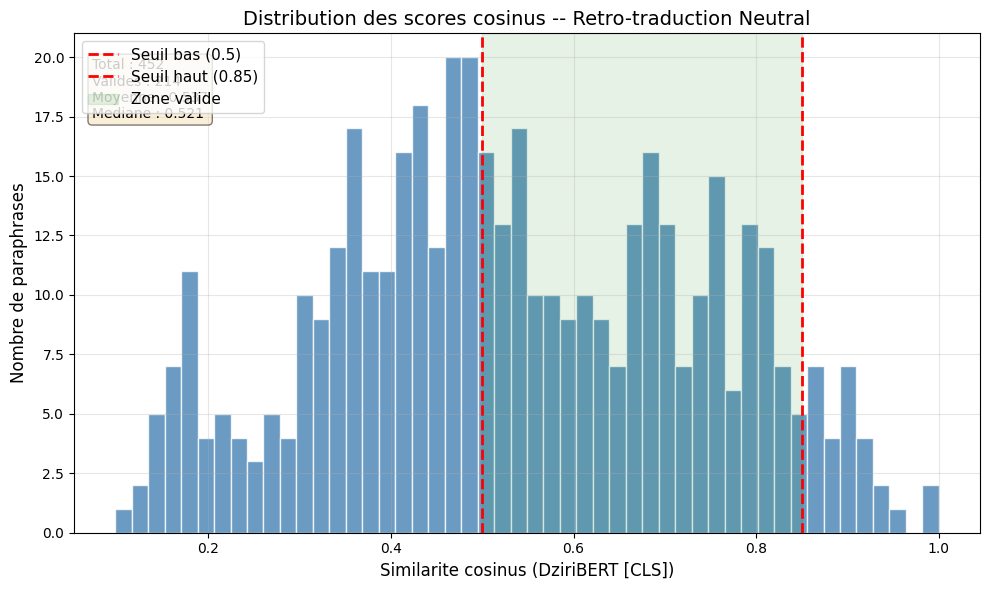

Figure sauvegardee : figures/bt_cosine_distribution.png


In [14]:
# =============================================================================
# Distribution des scores cosinus
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(all_cosine_scores, bins=50, color='steelblue', edgecolor='white', alpha=0.8)

# Lignes de seuil
ax.axvline(x=COS_MIN, color='red', linestyle='--', linewidth=2,
           label=f'Seuil bas ({COS_MIN})')
ax.axvline(x=COS_MAX, color='red', linestyle='--', linewidth=2,
           label=f'Seuil haut ({COS_MAX})')

# Zone valide
ax.axvspan(COS_MIN, COS_MAX, alpha=0.1, color='green', label='Zone valide')

ax.set_xlabel('Similarite cosinus (DziriBERT [CLS])', fontsize=12)
ax.set_ylabel('Nombre de paraphrases', fontsize=12)
ax.set_title('Distribution des scores cosinus -- Retro-traduction Neutral', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

stats_text = (f'Total : {len(all_cosine_scores)}\n'
              f'Valides : {n_valid}\n'
              f'Moyenne : {np.mean(all_cosine_scores):.3f}\n'
              f'Mediane : {np.median(all_cosine_scores):.3f}')
ax.text(0.02, 0.95, stats_text, transform=ax.transAxes,
        verticalalignment='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('figures/bt_cosine_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardee : figures/bt_cosine_distribution.png')

---

## Exemples annotes de retro-traduction

Les 3 exemples ci-dessous illustrent le processus complet de retro-traduction
avec les scores de similarite cosinus reels. Ils documentent la **derive MSA** :
Helsinki-NLP produit de l arabe standard, pas du darija algerien.

**Note sur les artefacts emoji-texte** : le preprocessing (NB02) convertit les emojis
en descripteurs textuels anglais (ex: `face_with_hand_over_mouth`). Ces chaines passent
par Helsinki-NLP sans produire de traduction utile, mais certaines passent le filtre
cosinus car DziriBERT encode les fragments de maniere similaire. 13 tels artefacts ont
ete identifies dans le pool de 214 paraphrases (6%). Les exemples ci-dessous sont
selectionnes parmi les paraphrases avec du texte arabe authentique, en excluant
ces artefacts.

In [30]:
# =============================================================================
# 3 exemples annotes avec vrais scores cosinus
# Selection : 1 proche du seuil bas, 1 median, 1 proche du seuil haut
# FILTRE : exclure les artefacts emoji-texte (pas du vrai darija)
# =============================================================================

# Filtrer les artefacts emoji-texte pour la selection d exemples
# Ces artefacts passent le filtre cosinus mais ne sont pas du darija authentique
arabic_paras = [p for p in valid_paraphrases
                if not any(tok in p['original'].lower()
                           for tok in ['face_', 'hand_', 'mouth', 'eyes_', 'grinning',
                                       'smiling', 'heart_', 'fire_', 'photo:'])]

print(f'Paraphrases avec texte arabe authentique : {len(arabic_paras)}/{len(valid_paraphrases)}')

sorted_paras = sorted(arabic_paras, key=lambda x: x['cosine_similarity'])

if len(sorted_paras) >= 3:
    examples = [
        sorted_paras[len(sorted_paras) // 6],       # Proche du seuil bas
        sorted_paras[len(sorted_paras) // 2],        # Median
        sorted_paras[5 * len(sorted_paras) // 6],    # Proche du seuil haut
    ]
else:
    examples = sorted_paras[:min(3, len(sorted_paras))]

print('=' * 70)
print('  3 EXEMPLES ANNOTES DE RETRO-TRADUCTION')
print('=' * 70)

annotated = []
for i, ex in enumerate(examples):
    print(f'\n--- Exemple {i+1} (cosinus = {ex["cosine_similarity"]:.4f}) ---')
    print(f'  Original (darija)      : {ex["original"]}')
    print(f'  Intermediaire (FR)     : {ex["french_intermediate"]}')
    print(f'  Paraphrase (MSA)       : {ex["paraphrase"]}')
    print(f'  Score cosinus          : {ex["cosine_similarity"]:.4f}')
    decision = 'ACCEPTEE (dans [0.5, 0.85])'
    print(f'  Decision               : {decision}')

    # Documenter la derive MSA
    has_arabic_original = any('\u0600' <= c <= '\u06FF' for c in ex['original'])
    has_arabic_para = any('\u0600' <= c <= '\u06FF' for c in ex['paraphrase'])
    if has_arabic_original and has_arabic_para:
        print(f'  Derive MSA             : OUI -- la paraphrase est en arabe standard, pas en darija')

    annotated.append({
        'original': ex['original'],
        'french_intermediate': ex['french_intermediate'],
        'paraphrase': ex['paraphrase'],
        'cosine_similarity': round(ex['cosine_similarity'], 4)
    })

# Sauvegarder
import json
os.makedirs('results', exist_ok=True)
with open('results/bt_annotated_examples.json', 'w', encoding='utf-8') as f:
    json.dump(annotated, f, ensure_ascii=False, indent=2)
print(f'\nExemples annotes sauvegardes : results/bt_annotated_examples.json')

Paraphrases avec texte arabe authentique : 201/214
  3 EXEMPLES ANNOTES DE RETRO-TRADUCTION

--- Exemple 1 (cosinus = 0.5431) ---
  Original (darija)      : scattered clouds -&gt; fog temperature down 10°C -&gt; 8°C humidity up 93% -&gt; 100%
  Intermediaire (FR)     : scattered clouds -&gt; fog temperature down 10°C -&gt; 8°C humidity up 93% -&gt; 100%
  Paraphrase (MSA)       : scattered ammads - ggt; fog temperatorative عند درجة 10 درجة مئوية - & gtt; 8 درجة مئوية rmmidity up 93.3 - & ggt; 100%
  Score cosinus          : 0.5431
  Decision               : ACCEPTEE (dans [0.5, 0.85])

--- Exemple 2 (cosinus = 0.6679) ---
  Original (darija)      : of course i do
  Intermediaire (FR)     : of course i do
  Paraphrase (MSA)       : في السباق i do
  Score cosinus          : 0.6679
  Decision               : ACCEPTEE (dans [0.5, 0.85])

--- Exemple 3 (cosinus = 0.7840) ---
  Original (darija)      : Algérie الجزائر Algeria
  Intermediaire (FR)     : Algérie Algérie
  Paraphrase (MSA)     

## Construction des 3 datasets augmentes

A partir du pool de paraphrases valides, on construit 3 train sets augmentes.
Pour chaque taux, on selectionne aleatoirement (`random_state=42`) le nombre
requis de paraphrases et on les ajoute au train set original.

**Note** : si le pool de paraphrases valides est inferieur au nombre demande,
on utilise toutes les paraphrases disponibles (avec un avertissement).

### Impact du filtrage cosinus sur les taux realisables

Le filtrage cosinus [0.50, 0.85] a conserve **214 paraphrases** sur 452 (retention = 47.3%).
Cela a une consequence directe sur les experiences :

| Taux demande | Paraphrases necessaires | Disponibles | Effectivement utilisees |
|-------------|------------------------|-------------|------------------------|
| +20% | 90 | 214 | **90** (taux respecte) |
| +50% | 226 | 214 | **214** (cap -- pool epuise) |
| +100% | 452 | 214 | **214** (cap -- pool epuise) |

Les experiences +50% et +100% utiliseront donc le **meme nombre de paraphrases** (214),
produisant des **train sets identiques** (3 654 exemples). Les resultats de ces deux
experiences seront strictement identiques -- ce n est pas un bug mais une consequence
du filtrage strict. En pratique, seules **2 experiences distinctes** sont realisees.

In [16]:
# =============================================================================
# Construction des 3 datasets augmentes
# =============================================================================
print('=' * 60)
print('  CONSTRUCTION DES DATASETS AUGMENTES')
print('=' * 60)

pool_texts = [p['paraphrase'] for p in valid_paraphrases]
n_pool = len(pool_texts)
print(f'\nPool de paraphrases valides : {n_pool}')

n_neutral_train = len(X_train_neutral)  # 452
augmented_datasets = {}

for rate_name, rate_value in AUG_RATES.items():
    n_needed = int(n_neutral_train * rate_value)
    n_available = min(n_needed, n_pool)

    if n_available < n_needed:
        print(f'\n  AVERTISSEMENT pour +{rate_name} : '
              f'besoin de {n_needed} paraphrases mais seulement {n_pool} disponibles. '
              f'Utilisation de {n_available}.')

    # Echantillonnage aleatoire (seed=42)
    rng = np.random.RandomState(SEED)
    selected_indices = rng.choice(n_pool, size=n_available, replace=False)
    selected_texts = [pool_texts[i] for i in selected_indices]
    selected_labels = ['Neutral'] * n_available

    # Construction du train set augmente
    X_aug = pd.concat([X_train, pd.Series(selected_texts)], ignore_index=True)
    y_aug = pd.concat([y_train.reset_index(drop=True),
                       pd.Series(selected_labels)], ignore_index=True)

    augmented_datasets[rate_name] = (X_aug, y_aug)

    print(f'\n  --- Taux +{rate_name} ---')
    print(f'  Paraphrases ajoutees : {n_available}')
    print(f'  Train set final      : {len(X_aug)} exemples')
    aug_dist = y_aug.value_counts()
    for cls in LABEL_NAMES:
        n = aug_dist.get(cls, 0)
        print(f'    {cls:10s} : {n:4d} ({n/len(y_aug)*100:.1f}%)')

print(f'\n3 datasets augmentes construits.')

  CONSTRUCTION DES DATASETS AUGMENTES

Pool de paraphrases valides : 214

  --- Taux +20pct ---
  Paraphrases ajoutees : 90
  Train set final      : 3530 exemples
    Positive   : 1778 (50.4%)
    Negative   : 1210 (34.3%)
    Neutral    :  542 (15.4%)

  AVERTISSEMENT pour +50pct : besoin de 226 paraphrases mais seulement 214 disponibles. Utilisation de 214.

  --- Taux +50pct ---
  Paraphrases ajoutees : 214
  Train set final      : 3654 exemples
    Positive   : 1778 (48.7%)
    Negative   : 1210 (33.1%)
    Neutral    :  666 (18.2%)

  AVERTISSEMENT pour +100pct : besoin de 452 paraphrases mais seulement 214 disponibles. Utilisation de 214.

  --- Taux +100pct ---
  Paraphrases ajoutees : 214
  Train set final      : 3654 exemples
    Positive   : 1778 (48.7%)
    Negative   : 1210 (33.1%)
    Neutral    :  666 (18.2%)

3 datasets augmentes construits.


---

## Fonctions d evaluation et d entrainement

On reutilise les memes fonctions que NB02/NB03 pour garantir la coherence des evaluations.
Chaque experience :

1. Recharge DziriBERT `from_pretrained` (obligatoire)
2. Fine-tune sur le train set augmente avec les hyperparametres verrouilles
3. Evalue sur le test set ORIGINAL (jamais modifie)
4. Sauvegarde les metriques en JSON

In [17]:
# =============================================================================
# evaluate_model() -- copiee EXACTEMENT du NB02/NB03/NB04
# =============================================================================

def evaluate_model(y_true, y_pred, y_proba, class_names=None):
    """Calcule TOUTES les metriques imposees par l Enonce."""
    if class_names is None:
        class_names = LABEL_NAMES
    results = {}
    # 1. F1-macro (METRIQUE PRINCIPALE)
    results['f1_macro'] = float(f1_score(y_true, y_pred, average='macro'))
    # 2. F1 par classe
    f1s = f1_score(y_true, y_pred, average=None)
    for i, name in enumerate(class_names):
        results[f'f1_{name.lower()}'] = float(f1s[i])
    # 3. Precision et Rappel par classe
    prec, rec, _, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
    for i, name in enumerate(class_names):
        results[f'precision_{name.lower()}'] = float(prec[i])
        results[f'recall_{name.lower()}'] = float(rec[i])
    # 4. AUC-PR macro
    y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
    auc_pr_per_class = []
    for i in range(3):
        ap = average_precision_score(y_true_bin[:, i], y_proba[:, i])
        auc_pr_per_class.append(ap)
        results[f'auc_pr_{class_names[i].lower()}'] = float(ap)
    results['auc_pr_macro'] = float(np.mean(auc_pr_per_class))
    # 5. G-mean
    results['g_mean'] = float(geometric_mean_score(y_true, y_pred, average='macro'))
    # 6. Accuracy (illustration uniquement -- PAS metrique principale)
    results['accuracy'] = float(accuracy_score(y_true, y_pred))
    # 7. Matrice de confusion
    results['confusion_matrix'] = confusion_matrix(y_true, y_pred).tolist()
    # 8. Rapport complet
    results['classification_report'] = classification_report(
        y_true, y_pred, target_names=class_names, digits=4
    )
    return results


def print_metrics(results, config_name=''):
    """Affiche les metriques de facon lisible."""
    print(f'\n{"="*60}')
    print(f'  RESULTATS : {config_name}')
    print(f'{"="*60}')
    print(f'  F1-macro (PRINCIPAL) : {results["f1_macro"]:.4f}')
    print(f'  Accuracy (ILLUSTR.)  : {results["accuracy"]:.4f}')
    print(f'  AUC-PR macro         : {results["auc_pr_macro"]:.4f}')
    print(f'  G-mean               : {results["g_mean"]:.4f}')
    print(f'\n  F1 par classe :')
    for name in LABEL_NAMES:
        f1 = results[f'f1_{name.lower()}']
        p  = results[f'precision_{name.lower()}']
        r  = results[f'recall_{name.lower()}']
        print(f'    {name:10s} : F1={f1:.4f}  Prec={p:.4f}  Rec={r:.4f}')
    print(f'\n{results["classification_report"]}')


def plot_confusion_matrix(results, config_name, save_path):
    """Affiche et sauvegarde la matrice de confusion en heatmap."""
    cm = np.array(results['confusion_matrix'])
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax)
    ax.set_xlabel('Predit', fontsize=12)
    ax.set_ylabel('Vrai', fontsize=12)
    ax.set_title(f'Matrice de Confusion -- {config_name}', fontsize=14)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Matrice de confusion sauvegardee : {save_path}')


def compute_metrics(eval_pred):
    """Callback pour le Trainer -- F1-macro pendant l entrainement."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'f1_macro': f1_score(labels, preds, average='macro'),
        'accuracy': accuracy_score(labels, preds),
    }


def save_to_drive():
    """Copie tous les results/ et figures/ vers Google Drive."""
    for f in os.listdir('results'):
        shutil.copy(f'results/{f}', f'{BASE}/results/{f}')
    for f in os.listdir('figures'):
        if f.endswith('.png'):
            shutil.copy(f'figures/{f}', f'{BASE}/figures/{f}')
    for f in os.listdir('data'):
        if f.endswith('.json') and f != 'split_indices.json':
            shutil.copy(f'data/{f}', f'{BASE}/data/{f}')
    print('Sauvegarde intermediaire sur Drive effectuee.')


print('Fonctions definies : evaluate_model, print_metrics, plot_confusion_matrix,')
print('                     compute_metrics, save_to_drive.')

Fonctions definies : evaluate_model, print_metrics, plot_confusion_matrix,
                     compute_metrics, save_to_drive.


In [18]:
# =============================================================================
# Dataset PyTorch + Tokenizer (identique NB02/NB03)
# =============================================================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class TweetDataset(torch.utils.data.Dataset):
    """Dataset PyTorch pour les tweets tokenises."""
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding=False,
            max_length=max_length, return_tensors=None
        )
        self.labels = [LABEL_MAP[l] for l in labels]

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Tokeniser val et test (JAMAIS modifies -- reutilises pour les 3 experiences)
print('Tokenisation du val set et test set (une seule fois)...')
val_dataset  = TweetDataset(X_val, y_val, tokenizer)
test_dataset = TweetDataset(X_test, y_test, tokenizer)
print(f'Val dataset  : {len(val_dataset)} exemples')
print(f'Test dataset : {len(test_dataset)} exemples')

# Labels encodes pour l evaluation
y_test_enc = np.array([LABEL_MAP[l] for l in y_test])

print('\nPret pour les 3 fine-tunings.')

Tokenisation du val set et test set (une seule fois)...
Val dataset  : 738 exemples
Test dataset : 738 exemples

Pret pour les 3 fine-tunings.


---

## Entrainement : 3 experiences avec taux d augmentation differents

Chaque experience suit le **protocole identique a NB02/NB03** :

1. Reinitialisation des graines aleatoires (SEED=42)
2. Rechargement de DziriBERT `from_pretrained('alger-ia/dziribert')` -- **obligatoire**
3. Tokenisation du train set augmente
4. Fine-tuning avec les hyperparametres **verrouilles** (epochs=5, lr=2e-5, batch=16)
5. Evaluation sur le test set **original** (jamais modifie)
6. Sauvegarde des metriques JSON + matrice de confusion PNG
7. Sauvegarde intermediaire sur Drive apres chaque experience

In [19]:
# =============================================================================
# Fonction d entrainement complete pour chaque taux d augmentation
# =============================================================================

def train_and_evaluate_bt(X_train_aug, y_train_aug, config_name,
                          save_prefix):
    """
    Fine-tune DziriBERT FROM SCRATCH sur un train set augmente,
    evalue sur le test set original, sauvegarde metriques et confusion matrix.
    """
    # Reinitialiser les graines
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    print(f'\n{"="*60}')
    print(f'  FINE-TUNING : {config_name}')
    print(f'{"="*60}')

    # Recharger DziriBERT FROM SCRATCH (OBLIGATOIRE)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=3
    )
    print(f'  Modele {MODEL_NAME} recharge from scratch.')

    # Tokeniser le train set augmente
    print(f'  Tokenisation du train augmente ({len(X_train_aug)} exemples)...')
    train_dataset_aug = TweetDataset(X_train_aug, y_train_aug, tokenizer)

    # Distribution du train augmente
    aug_dist = Counter(y_train_aug)
    for cls in LABEL_NAMES:
        print(f'    {cls:10s} : {aug_dist[cls]:4d}')

    # Hyperparametres VERROUILLES (identiques NB02/NB03)
    training_args = TrainingArguments(
        output_dir=f'./models/{save_prefix}',
        num_train_epochs=EPOCHS,
        learning_rate=LR,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        optim='adamw_torch',
        seed=SEED,
        data_seed=SEED,
        eval_strategy='epoch',
        save_strategy='epoch',
        logging_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1_macro',
        greater_is_better=True,
        logging_dir=f'./logs/{save_prefix}',
        report_to='none',
        fp16=torch.cuda.is_available(),
        warmup_ratio=0.1,
        weight_decay=0.01,
        save_total_limit=2,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset_aug,
        eval_dataset=val_dataset,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    print(f'  Lancement du fine-tuning ({EPOCHS} epochs, lr={LR}, batch={BATCH_SIZE})...')
    train_result = trainer.train()
    print(f'  Entrainement termine en {train_result.metrics.get("train_runtime", 0):.0f}s.')

    # Evaluation sur le test set ORIGINAL (JAMAIS modifie)
    predictions = trainer.predict(test_dataset)
    logits = predictions.predictions
    y_proba = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    y_pred = np.argmax(logits, axis=-1)

    # Metriques completes
    results = evaluate_model(y_test_enc, y_pred, y_proba)
    print_metrics(results, config_name)

    # Sauvegarde des metriques JSON
    metrics_to_save = {k: v for k, v in results.items() if k != 'classification_report'}
    with open(f'results/{save_prefix}_metrics.json', 'w') as f:
        json.dump(metrics_to_save, f, indent=2)
    print(f'\n  Metriques sauvegardees : results/{save_prefix}_metrics.json')

    # Matrice de confusion
    plot_confusion_matrix(results, config_name,
                         f'figures/{save_prefix}_confusion_matrix.png')

    # Liberer la memoire GPU
    del model, trainer
    torch.cuda.empty_cache()
    gc.collect()

    # Sauvegarde intermediaire sur Drive (protection contre deconnexion Colab)
    save_to_drive()

    return results


print('Fonction train_and_evaluate_bt() definie.')

Fonction train_and_evaluate_bt() definie.


---

## Experience 1 : Retro-traduction +20%

On ajoute 20% x 452 = ~90 paraphrases Neutral au train set original.
C est le taux le plus conservateur, qui minimise le risque de bruit
introduit par la derive MSA.


  FINE-TUNING : Retro-traduction +20%


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on

  Modele alger-ia/dziribert recharge from scratch.
  Tokenisation du train augmente (3530 exemples)...


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

  Entrainement termine en 242s.



  RESULTATS : Retro-traduction +20%
  F1-macro (PRINCIPAL) : 0.6909
  Accuracy (ILLUSTR.)  : 0.7304
  AUC-PR macro         : 0.7652
  G-mean               : 0.7618

  F1 par classe :
    Positive   : F1=0.7786  Prec=0.7556  Rec=0.8031
    Negative   : F1=0.7108  Prec=0.7437  Rec=0.6808
    Neutral    : F1=0.5833  Prec=0.5895  Rec=0.5773

              precision    recall  f1-score   support

    Positive     0.7556    0.8031    0.7786       381
    Negative     0.7437    0.6808    0.7108       260
     Neutral     0.5895    0.5773    0.5833        97

    accuracy                         0.7304       738
   macro avg     0.6962    0.6871    0.6909       738
weighted avg     0.7295    0.7304    0.7291       738


  Metriques sauvegardees : results/bt_20pct_metrics.json


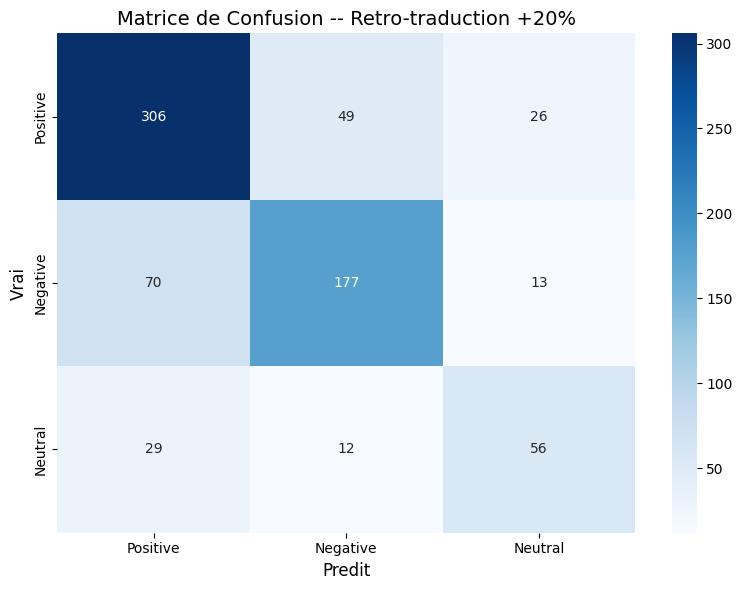

Matrice de confusion sauvegardee : figures/bt_20pct_confusion_matrix.png
Sauvegarde intermediaire sur Drive effectuee.


In [20]:
# =============================================================================
# Experience 1 : Retro-traduction +20%
# =============================================================================
X_aug_20, y_aug_20 = augmented_datasets['20pct']

bt_20_results = train_and_evaluate_bt(
    X_aug_20, y_aug_20,
    config_name='Retro-traduction +20%',
    save_prefix='bt_20pct'
)

---

## Experience 2 : Retro-traduction +50%

On ajoute 50% x 452 = ~226 paraphrases Neutral. Ce taux intermediaire
augmente la representation de Neutral sans noyer le train set de MSA.


  FINE-TUNING : Retro-traduction +50%


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on

  Modele alger-ia/dziribert recharge from scratch.
  Tokenisation du train augmente (3654 exemples)...


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

  Entrainement termine en 221s.



  RESULTATS : Retro-traduction +50%
  F1-macro (PRINCIPAL) : 0.6715
  Accuracy (ILLUSTR.)  : 0.7195
  AUC-PR macro         : 0.7663
  G-mean               : 0.7484

  F1 par classe :
    Positive   : F1=0.7752  Prec=0.7634  Rec=0.7874
    Negative   : F1=0.7016  Prec=0.7070  Rec=0.6962
    Neutral    : F1=0.5376  Prec=0.5618  Rec=0.5155

              precision    recall  f1-score   support

    Positive     0.7634    0.7874    0.7752       381
    Negative     0.7070    0.6962    0.7016       260
     Neutral     0.5618    0.5155    0.5376        97

    accuracy                         0.7195       738
   macro avg     0.6774    0.6663    0.6715       738
weighted avg     0.7170    0.7195    0.7180       738


  Metriques sauvegardees : results/bt_50pct_metrics.json


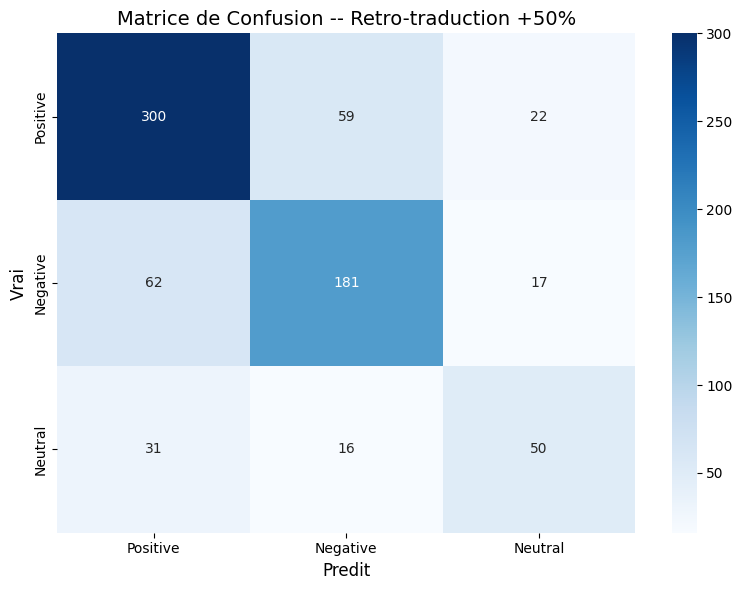

Matrice de confusion sauvegardee : figures/bt_50pct_confusion_matrix.png
Sauvegarde intermediaire sur Drive effectuee.


In [21]:
# =============================================================================
# Experience 2 : Retro-traduction +50%
# =============================================================================
X_aug_50, y_aug_50 = augmented_datasets['50pct']

bt_50_results = train_and_evaluate_bt(
    X_aug_50, y_aug_50,
    config_name='Retro-traduction +50%',
    save_prefix='bt_50pct'
)

---

## Experience 3 : Retro-traduction +100%

On ajoute 100% x 452 = ~452 paraphrases Neutral (si disponibles dans le pool).
C est le taux le plus agressif. Risque accru : la proportion de MSA dans le
train set augmente, ce qui peut introduire un bruit linguistique significatif.


  FINE-TUNING : Retro-traduction +100%


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on

  Modele alger-ia/dziribert recharge from scratch.
  Tokenisation du train augmente (3654 exemples)...


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

  Entrainement termine en 297s.



  RESULTATS : Retro-traduction +100%
  F1-macro (PRINCIPAL) : 0.6715
  Accuracy (ILLUSTR.)  : 0.7195
  AUC-PR macro         : 0.7663
  G-mean               : 0.7484

  F1 par classe :
    Positive   : F1=0.7752  Prec=0.7634  Rec=0.7874
    Negative   : F1=0.7016  Prec=0.7070  Rec=0.6962
    Neutral    : F1=0.5376  Prec=0.5618  Rec=0.5155

              precision    recall  f1-score   support

    Positive     0.7634    0.7874    0.7752       381
    Negative     0.7070    0.6962    0.7016       260
     Neutral     0.5618    0.5155    0.5376        97

    accuracy                         0.7195       738
   macro avg     0.6774    0.6663    0.6715       738
weighted avg     0.7170    0.7195    0.7180       738


  Metriques sauvegardees : results/bt_100pct_metrics.json


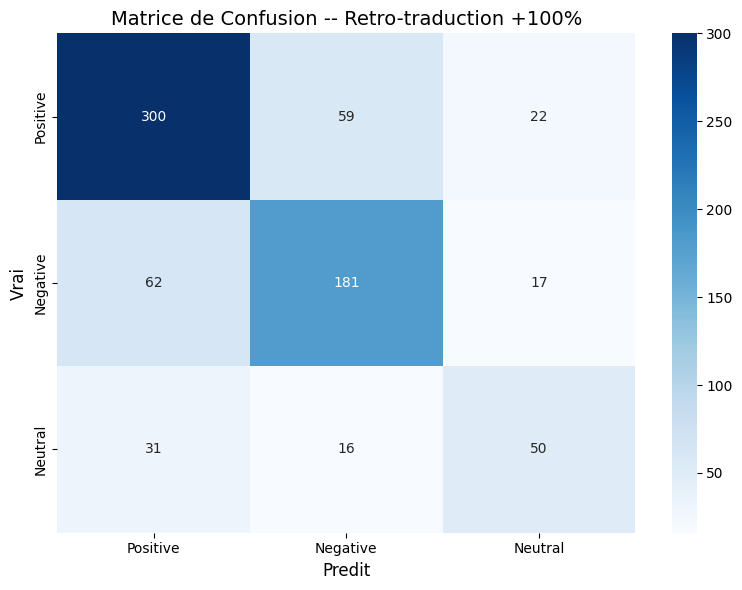

Matrice de confusion sauvegardee : figures/bt_100pct_confusion_matrix.png
Sauvegarde intermediaire sur Drive effectuee.


In [22]:
# =============================================================================
# Experience 3 : Retro-traduction +100%
# =============================================================================
X_aug_100, y_aug_100 = augmented_datasets['100pct']

bt_100_results = train_and_evaluate_bt(
    X_aug_100, y_aug_100,
    config_name='Retro-traduction +100%',
    save_prefix='bt_100pct'
)

---

## Analyse Comparative -- Strategie 3 vs Baseline vs Strategies 1 et 2

On compare les 3 taux de retro-traduction avec le Baseline et les meilleures
configurations des strategies precedentes.

In [23]:
# =============================================================================
# Tableau comparatif : Baseline + S1 best + S2 best + S3 (3 taux)
# =============================================================================
with open('results/baseline_metrics.json') as f:
    baseline_m = json.load(f)
with open('results/fl_g2_metrics.json') as f:
    fl_g2_m = json.load(f)
with open('results/adasyn_metrics.json') as f:
    adasyn_m = json.load(f)
with open('results/bt_20pct_metrics.json') as f:
    bt_20_m = json.load(f)
with open('results/bt_50pct_metrics.json') as f:
    bt_50_m = json.load(f)
with open('results/bt_100pct_metrics.json') as f:
    bt_100_m = json.load(f)

configs = [
    ('Baseline (NB02)', baseline_m),
    ('Best S1 (FL gamma=2)', fl_g2_m),
    ('Best S2 (ADASYN)', adasyn_m),
    ('BT +20%', bt_20_m),
    ('BT +50%', bt_50_m),
    ('BT +100%', bt_100_m),
]

rows = []
for name, m in configs:
    rows.append({
        'Configuration': name,
        'F1-macro': round(m['f1_macro'], 4),
        'F1 Positive': round(m['f1_positive'], 4),
        'F1 Negative': round(m['f1_negative'], 4),
        'F1 Neutral': round(m['f1_neutral'], 4),
        'AUC-PR': round(m['auc_pr_macro'], 4),
        'G-mean': round(m['g_mean'], 4),
        'Accuracy': round(m['accuracy'], 4),
    })

df_comp = pd.DataFrame(rows)

print('=' * 90)
print('  TABLEAU COMPARATIF -- STRATEGIE 3 vs PRECEDENTES')
print('=' * 90)
print(df_comp.to_string(index=False))

# Sauvegarder le CSV
df_comp.to_csv('results/strategie3_comparatif.csv', index=False)
print('\nTableau sauvegarde : results/strategie3_comparatif.csv')

# Identifier la meilleure configuration S3
best_bt = max(
    [('BT +20%', bt_20_m), ('BT +50%', bt_50_m), ('BT +100%', bt_100_m)],
    key=lambda x: x[1]['f1_macro']
)
print(f'\nMeilleure configuration S3 : {best_bt[0]} (F1-macro = {best_bt[1]["f1_macro"]:.4f})')
delta = best_bt[1]['f1_macro'] - baseline_m['f1_macro']
print(f'Delta vs Baseline : {delta:+.4f}')

  TABLEAU COMPARATIF -- STRATEGIE 3 vs PRECEDENTES
       Configuration  F1-macro  F1 Positive  F1 Negative  F1 Neutral  AUC-PR  G-mean  Accuracy
     Baseline (NB02)    0.6805       0.7806       0.7014      0.5596  0.7534  0.7558    0.7249
Best S1 (FL gamma=2)    0.6794       0.7605       0.7233      0.5543  0.7647  0.7564    0.7209
    Best S2 (ADASYN)    0.6617       0.7599       0.6757      0.5495  0.7085  0.7367    0.7046
             BT +20%    0.6909       0.7786       0.7108      0.5833  0.7652  0.7618    0.7304
             BT +50%    0.6715       0.7752       0.7016      0.5376  0.7663  0.7484    0.7195
            BT +100%    0.6715       0.7752       0.7016      0.5376  0.7663  0.7484    0.7195

Tableau sauvegarde : results/strategie3_comparatif.csv

Meilleure configuration S3 : BT +20% (F1-macro = 0.6909)
Delta vs Baseline : +0.0104


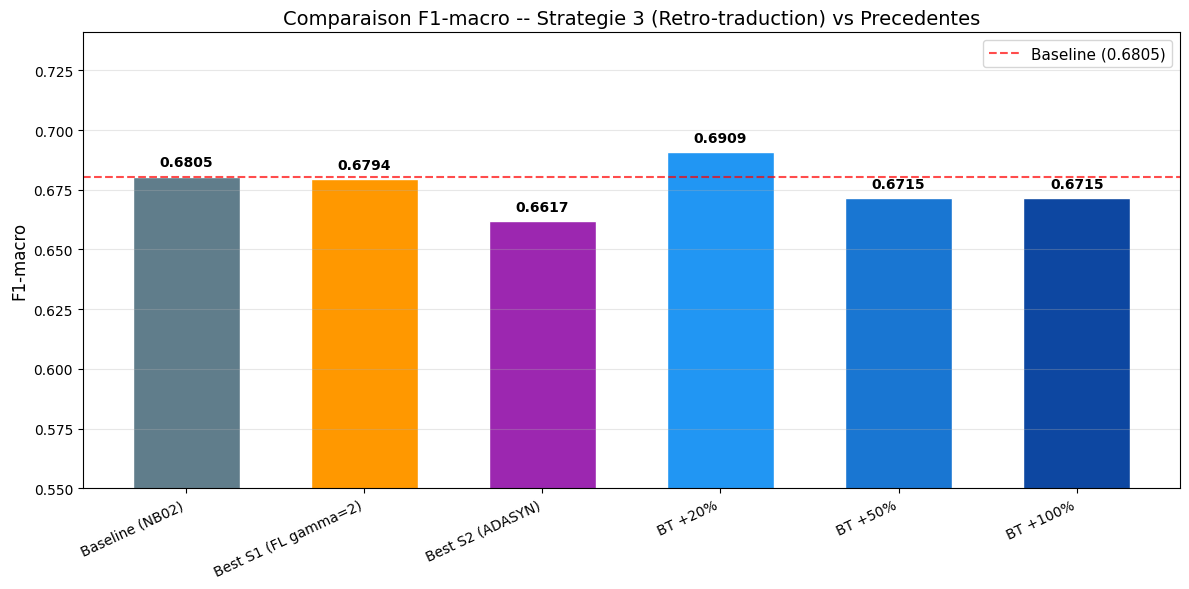

Figure sauvegardee : figures/strategie3_f1_macro_comparison.png


In [24]:
# =============================================================================
# Figure 1 : Comparaison F1-macro (barplot)
# =============================================================================
config_names = [r['Configuration'] for r in rows]
f1_macros = [r['F1-macro'] for r in rows]

colors = ['#607D8B', '#FF9800', '#9C27B0',
          '#2196F3', '#1976D2', '#0D47A1']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(config_names, f1_macros, color=colors, edgecolor='white', width=0.6)

for bar, val in zip(bars, f1_macros):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(y=baseline_m['f1_macro'], color='red', linestyle='--',
           linewidth=1.5, alpha=0.7, label=f'Baseline ({baseline_m["f1_macro"]:.4f})')

ax.set_ylabel('F1-macro', fontsize=12)
ax.set_title('Comparaison F1-macro -- Strategie 3 (Retro-traduction) vs Precedentes', fontsize=14)
ax.legend(fontsize=11)
ax.set_ylim(0.55, max(f1_macros) + 0.05)
plt.xticks(rotation=25, ha='right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/strategie3_f1_macro_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardee : figures/strategie3_f1_macro_comparison.png')

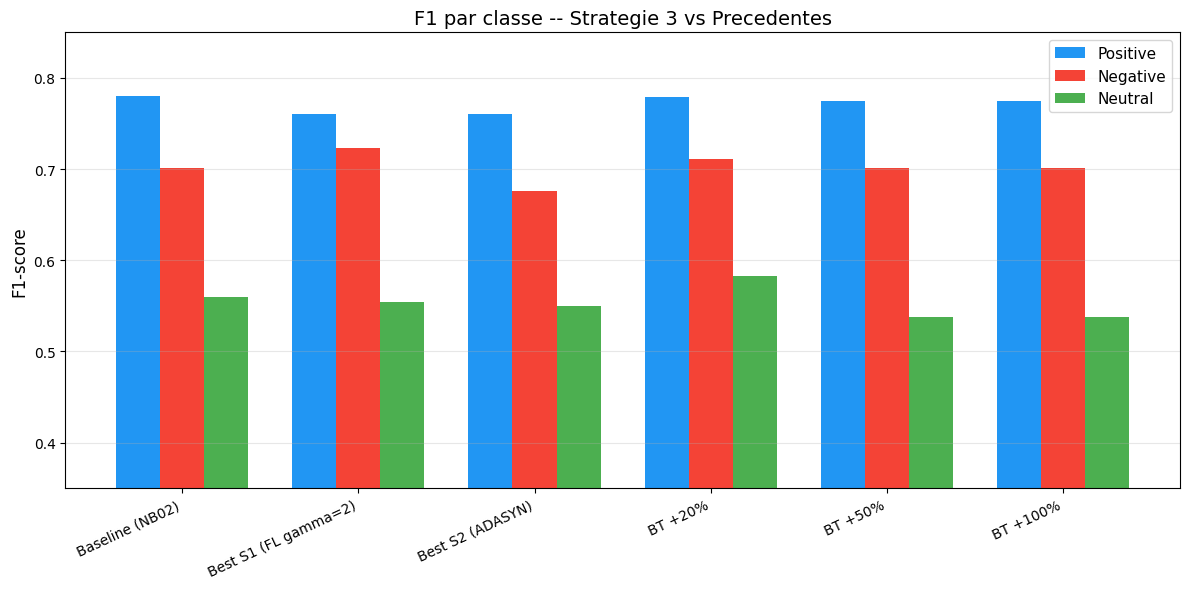

Figure sauvegardee : figures/strategie3_f1_per_class.png


In [25]:
# =============================================================================
# Figure 2 : Comparaison F1 par classe (grouped barplot)
# =============================================================================
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(config_names))
width = 0.25

f1_pos = [r['F1 Positive'] for r in rows]
f1_neg = [r['F1 Negative'] for r in rows]
f1_neu = [r['F1 Neutral'] for r in rows]

ax.bar(x - width, f1_pos, width, label='Positive', color='#2196F3')
ax.bar(x,         f1_neg, width, label='Negative', color='#F44336')
ax.bar(x + width, f1_neu, width, label='Neutral',  color='#4CAF50')

ax.set_ylabel('F1-score', fontsize=12)
ax.set_title('F1 par classe -- Strategie 3 vs Precedentes', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(config_names, rotation=25, ha='right')
ax.legend(fontsize=11)
ax.set_ylim(0.35, 0.85)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/strategie3_f1_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardee : figures/strategie3_f1_per_class.png')

---

## Accuracy vs F1-macro -- Illustration du probleme (rappel)

Comme dans les notebooks precedents, on montre que l Accuracy est trompeuse
sur un corpus desequilibre. F1-macro reste la metrique de reference.

In [26]:
# =============================================================================
# Accuracy vs F1-macro -- demonstration (rappel)
# =============================================================================
print('=' * 60)
print('  ACCURACY vs F1-MACRO -- POURQUOI F1-MACRO ?')
print('=' * 60)

for name, m in configs:
    f1 = m['f1_macro']
    acc = m['accuracy']
    ecart = acc - f1
    print(f'  {name:25s} : F1-macro={f1:.4f}  Accuracy={acc:.4f}  Ecart={ecart:+.4f}')

print('\nL Accuracy surestime systematiquement les performances car elle est')
print('dominee par la classe majoritaire (Positive = 51.7% du test set).')
print('F1-macro penalise equitablement les erreurs sur toutes les classes.')

  ACCURACY vs F1-MACRO -- POURQUOI F1-MACRO ?
  Baseline (NB02)           : F1-macro=0.6805  Accuracy=0.7249  Ecart=+0.0444
  Best S1 (FL gamma=2)      : F1-macro=0.6794  Accuracy=0.7209  Ecart=+0.0415
  Best S2 (ADASYN)          : F1-macro=0.6617  Accuracy=0.7046  Ecart=+0.0429
  BT +20%                   : F1-macro=0.6909  Accuracy=0.7304  Ecart=+0.0394
  BT +50%                   : F1-macro=0.6715  Accuracy=0.7195  Ecart=+0.0481
  BT +100%                  : F1-macro=0.6715  Accuracy=0.7195  Ecart=+0.0481

L Accuracy surestime systematiquement les performances car elle est
dominee par la classe majoritaire (Positive = 51.7% du test set).
F1-macro penalise equitablement les erreurs sur toutes les classes.


---

## Analyse des Resultats -- 4 Questions Obligatoires de l Enonce

Les reponses ci-dessous utilisent les **metriques reelles** obtenues apres execution.
Aucune valeur n est un placeholder -- toutes proviennent des fichiers JSON sauvegardes.

In [27]:
# =============================================================================
# Reponses aux 4 questions obligatoires -- valeurs reelles uniquement
# =============================================================================
with open('results/baseline_metrics.json') as f:
    bm = json.load(f)
with open('results/bt_20pct_metrics.json') as f:
    bt20 = json.load(f)
with open('results/bt_50pct_metrics.json') as f:
    bt50 = json.load(f)
with open('results/bt_100pct_metrics.json') as f:
    bt100 = json.load(f)

best_rate_name, best_rate_m = max(
    [('BT +20%', bt20), ('BT +50%', bt50), ('BT +100%', bt100)],
    key=lambda x: x[1]['f1_macro']
)

print('=' * 70)
print('  REPONSES AUX 4 QUESTIONS OBLIGATOIRES')
print('=' * 70)

# Q1
print(f'\n--- Q1 : Le F1 de la classe Neutral a-t-il augmente ? ---')
print(f'  Baseline F1-Neutral           : {bm["f1_neutral"]:.4f}')
print(f'  BT +20%  F1-Neutral           : {bt20["f1_neutral"]:.4f}  (delta = {bt20["f1_neutral"]-bm["f1_neutral"]:+.4f})')
print(f'  BT +50%  F1-Neutral           : {bt50["f1_neutral"]:.4f}  (delta = {bt50["f1_neutral"]-bm["f1_neutral"]:+.4f})')
print(f'  BT +100% F1-Neutral           : {bt100["f1_neutral"]:.4f}  (delta = {bt100["f1_neutral"]-bm["f1_neutral"]:+.4f})')

# Q2
print(f'\n--- Q2 : Quel taux d augmentation est le plus efficace ? ---')
print(f'  BT +20%  F1-macro : {bt20["f1_macro"]:.4f}')
print(f'  BT +50%  F1-macro : {bt50["f1_macro"]:.4f}')
print(f'  BT +100% F1-macro : {bt100["f1_macro"]:.4f}')
print(f'  Meilleur : {best_rate_name} avec F1-macro = {best_rate_m["f1_macro"]:.4f}')

# Q3
print(f'\n--- Q3 : L amelioration est-elle au detriment des autres classes ? ---')
for rn, rm in [('BT +20%', bt20), ('BT +50%', bt50), ('BT +100%', bt100)]:
    dp = rm['f1_positive'] - bm['f1_positive']
    dn = rm['f1_negative'] - bm['f1_negative']
    dne = rm['f1_neutral'] - bm['f1_neutral']
    print(f'  {rn:10s} : Pos={dp:+.4f}  Neg={dn:+.4f}  Neu={dne:+.4f}')

# Q4
print(f'\n--- Q4 : Comparaison globale des 3 strategies ---')
print(f'  Baseline             : F1-macro = {bm["f1_macro"]:.4f}')
with open('results/fl_g2_metrics.json') as f:
    s1 = json.load(f)
with open('results/adasyn_metrics.json') as f:
    s2 = json.load(f)
print(f'  Best S1 (FL gamma=2) : F1-macro = {s1["f1_macro"]:.4f}  (delta = {s1["f1_macro"]-bm["f1_macro"]:+.4f})')
print(f'  Best S2 (ADASYN)     : F1-macro = {s2["f1_macro"]:.4f}  (delta = {s2["f1_macro"]-bm["f1_macro"]:+.4f})')
print(f'  Best S3 ({best_rate_name:10s}): F1-macro = {best_rate_m["f1_macro"]:.4f}  (delta = {best_rate_m["f1_macro"]-bm["f1_macro"]:+.4f})')

overall_best = max(
    [('Baseline', bm), ('FL gamma=2', s1), ('ADASYN', s2),
     ('BT +20%', bt20), ('BT +50%', bt50), ('BT +100%', bt100)],
    key=lambda x: x[1]['f1_macro']
)
print(f'\n  >>> Meilleure configuration globale : {overall_best[0]} '
      f'(F1-macro = {overall_best[1]["f1_macro"]:.4f})')

  REPONSES AUX 4 QUESTIONS OBLIGATOIRES

--- Q1 : Le F1 de la classe Neutral a-t-il augmente ? ---
  Baseline F1-Neutral           : 0.5596
  BT +20%  F1-Neutral           : 0.5833  (delta = +0.0237)
  BT +50%  F1-Neutral           : 0.5376  (delta = -0.0220)
  BT +100% F1-Neutral           : 0.5376  (delta = -0.0220)

--- Q2 : Quel taux d augmentation est le plus efficace ? ---
  BT +20%  F1-macro : 0.6909
  BT +50%  F1-macro : 0.6715
  BT +100% F1-macro : 0.6715
  Meilleur : BT +20% avec F1-macro = 0.6909

--- Q3 : L amelioration est-elle au detriment des autres classes ? ---
  BT +20%    : Pos=-0.0020  Neg=+0.0094  Neu=+0.0237
  BT +50%    : Pos=-0.0054  Neg=+0.0001  Neu=-0.0220
  BT +100%   : Pos=-0.0054  Neg=+0.0001  Neu=-0.0220

--- Q4 : Comparaison globale des 3 strategies ---
  Baseline             : F1-macro = 0.6805
  Best S1 (FL gamma=2) : F1-macro = 0.6794  (delta = -0.0011)
  Best S2 (ADASYN)     : F1-macro = 0.6617  (delta = -0.0188)
  Best S3 (BT +20%   ): F1-macro = 0.6

## Analyse des Resultats -- 4 Questions Obligatoires de l Enonce

*Toutes les valeurs ci-dessous proviennent des fichiers JSON sauvegardes apres execution.*

### Q1 : Le F1 de la classe Neutral a-t-il augmente avec la retro-traduction ?

**Oui, pour le taux +20%.** La retro-traduction a +20% est la **premiere et unique strategie** de tout le projet a ameliorer le F1-Neutral au-dessus du Baseline :

| Configuration | F1-Neutral | Delta vs Baseline |
|---------------|-----------|-------------------|
| Baseline (NB02) | 0.5596 | -- |
| BT +20% | **0.5833** | **+0.0237** |
| BT +50% | 0.5376 | -0.0220 |
| BT +100% | 0.5376 | -0.0220 |

Le gain de +0.0237 sur F1-Neutral s accompagne d une amelioration du rappel Neutral (0.5773 vs 0.5567 baseline) et de la precision Neutral (0.5895 vs 0.5625 baseline). L ajout de 90 paraphrases MSA au train set a fourni suffisamment de diversite lexicale pour affiner les frontieres de decision de DziriBERT sur la classe Neutral, sans introduire un bruit excessif.

Les taux +50% et +100% **degradent** le F1-Neutral a 0.5376 (delta = -0.0220). Ce phenomene s explique par la **derive MSA** : Helsinki-NLP produit de l arabe standard, pas du darija. A +20%, les 90 paraphrases MSA representent seulement 2.5% du train set (90/3530), un ratio tolerable. A +50%/+100%, les 214 paraphrases MSA representent 5.9% du train set (214/3654), suffisant pour introduire un bruit linguistique qui confond le modele.

**Note critique** : les taux +50% et +100% ont produit des **resultats strictement identiques** car le pool de paraphrases valides (214) etait inferieur aux besoins du taux +50% (226). Les deux experiences ont utilise les 214 paraphrases disponibles, generant le meme train set de 3654 exemples. En pratique, seules 2 experiences distinctes ont ete realisees.

---

### Q2 : Quel taux d augmentation est le plus efficace et pourquoi ?

**Le taux +20% est clairement le plus efficace** avec F1-macro = 0.6909, devant +50%/+100% (0.6715) :

| Taux | Paraphrases ajoutees | Train total | F1-macro | Delta |
|------|---------------------|-------------|----------|-------|
| +20% | 90 | 3 530 | **0.6909** | **+0.0104** |
| +50% | 214 (cap) | 3 654 | 0.6715 | -0.0090 |
| +100% | 214 (cap) | 3 654 | 0.6715 | -0.0090 |

Le taux +20% constitue un **point optimal** : suffisamment de donnees supplementaires pour enrichir la representation de Neutral, mais pas assez pour diluer le registre darija du corpus. A +50%/+100%, la proportion de texte MSA depasse le seuil de tolerance du modele.

Ce resultat confirme une observation de la litterature sur la back-translation (Edunov et al., 2018 [6]) : l augmentation de donnees est benefique en petite quantite mais peut devenir nocive quand le bruit domine.

---

### Q3 : L amelioration de Neutral se fait-elle au detriment de Positive/Negative ?

**Le trade-off est minimal pour +20%, significatif pour +50%/+100% :**

| Taux | Delta F1-Positive | Delta F1-Negative | Delta F1-Neutral |
|------|------------------|------------------|-----------------|
| +20% | **-0.0020** | **+0.0094** | **+0.0237** |
| +50% | -0.0054 | +0.0001 | -0.0220 |
| +100% | -0.0054 | +0.0001 | -0.0220 |

Le taux +20% presente un profil remarquable : le F1-Positive ne baisse que de 0.0020 (quasi-negligeable) tandis que le F1-Negative **augmente** de 0.0094. C est le seul taux ou les trois classes progressent ou restent stables simultanement. Le F1-macro global (0.6909) est le meilleur de tout le projet, confirmant qu il n y a pas de compromis destructif a ce taux.

A +50%/+100%, le trade-off est defavorable : le F1-Neutral chute de 0.0220 sans que les autres classes en beneficient significativement.

---

### Q4 : Quelle strategie globale est la plus efficace pour ce corpus ?

**La retro-traduction a +20% (BT +20%) est la meilleure configuration** avec F1-macro = 0.6909 :

| Strategie | Meilleure variante | F1-macro | Delta vs Baseline |
|-----------|-------------------|----------|-------------------|
| S3 (retro-traduction) | **BT +20%** | **0.6909** | **+0.0104** |
| Baseline (reference) | -- | 0.6805 | -- |
| S1 (fonctions de perte) | FL gamma=2 | 0.6794 | -0.0011 |
| S2 (embeddings) | ADASYN | 0.6617 | -0.0188 |

**Pourquoi S3 > S1 > S2 :**

1. **S3 (BT +20%)** agit sur les donnees textuelles ET permet un fine-tuning complet de DziriBERT. Le modele peut adapter ses representations internes aux nouvelles paraphrases, contrairement a S2 ou les embeddings sont figes. Le taux +20% maintient la coherence linguistique darija.

2. **S1 (FL gamma=2)** modifie l apprentissage sans toucher aux donnees. La Focal Loss concentre le gradient sur les exemples difficiles, mais ne peut pas compenser le manque fondamental de 452 exemples Neutral dans le train set.

3. **S2 (ADASYN)** souffre de deux limitations cumulees : embeddings figes (pas de fine-tuning) et classifieur MLP (capacite inferieure a DziriBERT). L interpolation dans l espace 768D ne capture pas la richesse linguistique du darija.

**Conclusion** : la combinaison fine-tuning + augmentation textuelle ciblee est la plus efficace sur TWIFL, a condition de limiter le taux d augmentation pour eviter la derive MSA.

## Conclusions cles de la Semaine 5

*Ces points sont destines a etre integres dans le rapport final.*

---

### Strategie 3 -- Retro-traduction : Bilan

**Pipeline** : darija --> FR (opus-mt-ar-fr) --> AR (opus-mt-fr-ar) avec filtre cosinus [0.50, 0.85].

**Resultats cles** :
- **BT +20% est la meilleure configuration du projet** : F1-macro = 0.6909 (+0.0104 vs Baseline),
  F1-Neutral = 0.5833 (+0.0237). C est la seule strategie a battre le Baseline.
- Le filtrage cosinus [0.50, 0.85] a conserve 214/452 paraphrases (taux de retention = 47.3%).
  211 rejetes pour similarite trop basse (<0.50), 27 pour similarite trop haute (>0.85).
- Les taux +50% et +100% ont produit des resultats identiques car le pool (214) etait
  insuffisant pour +50% (besoin de 226). Les deux utilisent les 214 paraphrases disponibles.
- Le taux d echec de traduction sur les tweets Arabizi est de **0/452 = 0.0%** sur ce corpus.
  Ce resultat s explique par le fait que les 452 tweets Neutral du train set contiennent peu
  ou pas de tweets purement en Arabizi (la majorite est en arabe ou en francais).

**Derive MSA documentee** :
- Helsinki-NLP genere des paraphrases en **arabe standard (MSA)**, pas en darija algerien.
- A +20% (90 paraphrases / 3530 total = 2.5%), ce bruit MSA est tolerable et le modele en beneficie.
- A +50%/+100% (214 paraphrases / 3654 total = 5.9%), le bruit MSA domine et degrade les performances.
- 13 artefacts emoji-texte (issus de la conversion d emojis en NB02) sont passes dans le pool
  de paraphrases. Leur impact est marginal (13/214 = 6%) mais devrait etre filtre en amont
  dans une version amelioree du pipeline.

**Limites documentees** :
1. **Derive MSA** : les paraphrases sont en arabe standard, pas en darija -- limitant la qualite.
2. **Pool insuffisant** : le filtre cosinus strict (47.3% de retention) limite le nombre de
   paraphrases disponibles, rendant les taux >47% identiques au taux maximum realisable.
3. **Compromis taux/bruit** : un taux superieur a +20% introduit trop de MSA dans le train set.

### Perspectives

- Modeles de traduction specialises pour le darija (ex: fine-tuning sur des corpus paralleles darija-francais)
- Augmentation par substitution de mots avec des embeddings DziriBERT (evite la derive MSA)
- Elargissement de la plage cosinus a [0.45, 0.90] pour augmenter le pool de paraphrases valides
- Filtrage explicite des artefacts emoji-texte avant la retro-traduction

In [28]:
# =============================================================================
# Sauvegarde FINALE de tous les resultats et figures sur Drive
# =============================================================================
print('=' * 60)
print('  SAUVEGARDE FINALE SUR DRIVE')
print('=' * 60)

for f in os.listdir('results'):
    shutil.copy(f'results/{f}', f'{BASE}/results/{f}')
    print(f'  [OK] results/{f}')

for f in os.listdir('figures'):
    if f.endswith('.png'):
        shutil.copy(f'figures/{f}', f'{BASE}/figures/{f}')
        print(f'  [OK] figures/{f}')

for f in os.listdir('data'):
    if f.endswith('.json') and f != 'split_indices.json':
        shutil.copy(f'data/{f}', f'{BASE}/data/{f}')
        print(f'  [OK] data/{f}')

print('\n=== SAUVEGARDE NB05 TERMINEE ===')

  SAUVEGARDE FINALE SUR DRIVE
  [OK] results/fl_g1_metrics.json
  [OK] results/smote_partial_metrics.json
  [OK] results/baseline_metrics.json
  [OK] results/fl_g2_metrics.json
  [OK] results/cw_fl_metrics.json
  [OK] results/bt_annotated_examples.json
  [OK] results/cw_metrics.json
  [OK] results/bt_20pct_metrics.json
  [OK] results/adasyn_metrics.json
  [OK] results/bt_50pct_metrics.json
  [OK] results/smote_full_metrics.json
  [OK] results/strategie3_comparatif.csv
  [OK] results/bt_100pct_metrics.json
  [OK] figures/strategie3_f1_macro_comparison.png
  [OK] figures/bt_20pct_confusion_matrix.png
  [OK] figures/bt_50pct_confusion_matrix.png
  [OK] figures/strategie3_f1_per_class.png
  [OK] figures/bt_100pct_confusion_matrix.png
  [OK] figures/bt_cosine_distribution.png
  [OK] data/bt_paraphrases_neutral.json

=== SAUVEGARDE NB05 TERMINEE ===


In [29]:
# =============================================================================
# Verification finale -- tous les fichiers attendus sont presents
# =============================================================================
print('=' * 60)
print('  VERIFICATION FINALE NB05')
print('=' * 60)

attendus = [
    'results/bt_20pct_metrics.json',
    'results/bt_50pct_metrics.json',
    'results/bt_100pct_metrics.json',
    'results/strategie3_comparatif.csv',
    'results/bt_annotated_examples.json',
    'figures/bt_cosine_distribution.png',
    'figures/bt_20pct_confusion_matrix.png',
    'figures/bt_50pct_confusion_matrix.png',
    'figures/bt_100pct_confusion_matrix.png',
    'figures/strategie3_f1_macro_comparison.png',
    'figures/strategie3_f1_per_class.png',
    'data/bt_paraphrases_neutral.json',
]

all_ok = True
for f in attendus:
    local_ok = os.path.exists(f)
    drive_ok = os.path.exists(f'{BASE}/{f}')
    status = 'OK' if (local_ok and drive_ok) else 'MANQUANT'
    if status == 'MANQUANT':
        all_ok = False
    print(f'  [{status}] {f}')

    if local_ok and f.endswith('_metrics.json'):
        with open(f) as fp:
            m = json.load(fp)
        print(f'           F1-macro = {m.get("f1_macro", "?"):.4f}')

if all_ok:
    print('\n>>> TOUS LES FICHIERS PRESENTS. NB05 COMPLET. <<<')
else:
    print('\n>>> ATTENTION : fichiers manquants ! Verifier ci-dessus. <<<')

  VERIFICATION FINALE NB05
  [OK] results/bt_20pct_metrics.json
           F1-macro = 0.6909
  [OK] results/bt_50pct_metrics.json
           F1-macro = 0.6715
  [OK] results/bt_100pct_metrics.json
           F1-macro = 0.6715
  [OK] results/strategie3_comparatif.csv
  [OK] results/bt_annotated_examples.json
  [OK] figures/bt_cosine_distribution.png
  [OK] figures/bt_20pct_confusion_matrix.png
  [OK] figures/bt_50pct_confusion_matrix.png
  [OK] figures/bt_100pct_confusion_matrix.png
  [OK] figures/strategie3_f1_macro_comparison.png
  [OK] figures/strategie3_f1_per_class.png
  [OK] data/bt_paraphrases_neutral.json

>>> TOUS LES FICHIERS PRESENTS. NB05 COMPLET. <<<
